# 📊 Data Analytics for Business and Healthcare
### Hands-On Lab — Case Study: COVID-19 in Malaysia

Welcome! This notebook is your hands-on lab for the short course **Data Analytics for Business and Healthcare**.

**You do NOT need any coding or IT background.** Every code cell below is already written for you — your job is simply to:

1. Click on a grey code cell (called a **cell**)
2. Press the ▶️ **Run** button on its left (or press `Shift + Enter`)
3. Read the short explanation, look at the result, then move to the next cell

Run the cells **in order, from top to bottom** — later cells depend on earlier ones.

---
📁 **Before you start:** make sure you have downloaded `covid19_malaysia_cases.csv` from the course materials. You will upload it in Step 1 below.

📄 A full written version of these instructions is also available in the **Hands-On Lab Manual (Word document)** provided with this course.


##Meet Google Colab

This page is a **Google Colab notebook**. It runs Python code inside your web browser — nothing to install.

A notebook is made of **cells**:
- 📝 **Text cells** (like this one) contain instructions
- 💻 **Code cells** (grey background) contain Python code you can run

Let's run our very first line of code. Click the cell below and press ▶️.

In [ ]:
# This is a code cell. Click the ▶ button on the left, or press Shift+Enter, to run it.
print("Hello! Welcome to Data Analytics for Business and Healthcare 🎉")

Hello! Welcome to Data Analytics for Business and Healthcare 🎉


In [ ]:
import pandas as pd
url="https://raw.githubusercontent.com/MoH-Malaysia/covid19-public/main/epidemic/cases_malaysia.csv"
df = pd.read_csv(url)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded and ready to use ✅")

Libraries loaded and ready to use ✅


Every data analysis starts the same way: **look at your data before doing anything else.**

- `df.head()` shows the first 5 rows
- `df.shape` shows (number of rows, number of columns)
- `df.info()` shows every column name and its data type

In [ ]:
df.head()

,date,cases_new,cases_import,cases_recovered,cases_active,cases_cluster,cases_unvax,cases_pvax,cases_fvax,cases_boost,...,cases_60_69,cases_70_79,cases_80,cluster_import,cluster_religious,cluster_community,cluster_highRisk,cluster_education,cluster_detentionCentre,cluster_workplace
0,2020-01-25,4,4,0,4,0,4,0,0,0,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-26,0,0,0,4,0,0,0,0,0,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-27,0,0,0,4,0,0,0,0,0,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-28,0,0,0,4,0,0,0,0,0,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-29,3,3,0,7,0,3,0,0,0,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(1954, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1954 entries, 0 to 1953
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     1954 non-null   object 
 1   cases_new                1954 non-null   int64  
 2   cases_import             1954 non-null   int64  
 3   cases_recovered          1954 non-null   int64  
 4   cases_active             1954 non-null   int64  
 5   cases_cluster            1954 non-null   int64  
 6   cases_unvax              1954 non-null   int64  
 7   cases_pvax               1954 non-null   int64  
 8   cases_fvax               1954 non-null   int64  
 9   cases_boost              1954 non-null   int64  
 10  cases_child              1954 non-null   int64  
 11  cases_adolescent         1954 non-null   int64  
 12  cases_adult              1954 non-null   int64  
 13  cases_elderly            1954 non-null   int64  
 14  cases_0_4               

**Column meanings:**

| Column | Meaning |
|---|---|
| `date` | The calendar date |
| `cases_new` | Newly confirmed COVID-19 cases that day |
| `cases_import` | New cases that were imported from abroad |
| `cases_recovered` | Patients who recovered that day |
| `cases_active` | Total patients currently infected (active cases) |
| `deaths_new` | COVID-19 deaths recorded that day |
| `vax_daily_doses` | Vaccine doses administered that day |
| `vax_cumul_fully_vaccinated` | Running total of fully vaccinated people |
| `vax_cumul_booster` | Running total of booster doses given |


## Data Cleaning Basics

Real-world data is rarely perfect. Before analyzing, we check for **missing values** and make sure each column has the right **data type**.

In [ ]:
# Count missing values in every column
df.isnull().sum()

,0
date,0
cases_new,0
cases_import,0
cases_recovered,0
cases_active,0
cases_cluster,0
cases_unvax,0
cases_pvax,0
cases_fvax,0
cases_boost,0


In [ ]:
# Convert the 'date' column from plain text into a proper date type
# This lets Python understand it as a timeline (so it can sort, plot, and calculate with it correctly)
df['date'] = pd.to_datetime(df['date'])

print("Data type of 'date' column is now:", df['date'].dtype)

Data type of 'date' column is now: datetime64[ns]


## Descriptive Statistics

`df.describe()` instantly summarizes every numeric column: the average, minimum, maximum, and how spread out the values are.

This is **Descriptive Analytics** — the first of the four types of analytics we discussed in the lecture (Descriptive, Diagnostic, Predictive, Prescriptive).

In [ ]:
df.describe()

,date,cases_new,cases_import,cases_recovered,cases_active,cases_cluster,cases_unvax,cases_pvax,cases_fvax,cases_boost,...,cases_60_69,cases_70_79,cases_80,cluster_import,cluster_religious,cluster_community,cluster_highRisk,cluster_education,cluster_detentionCentre,cluster_workplace
count,1954,1954.000000,1954.000000,1954.000000,1954.000000,1954.000000,1954.000000,1954.000000,1954.000000,1954.000000,...,1954.000000,1954.000000,1954.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,2022-09-27 12:00:00,2736.260491,20.123849,2709.574719,34667.890481,273.572160,1048.888434,223.628454,728.679632,731.899181,...,153.493859,70.528659,37.897134,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2020-01-25 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2021-05-27 06:00:00,112.000000,0.000000,98.000000,8298.250000,0.000000,21.000000,0.000000,4.250000,0.000000,...,5.000000,3.000000,6.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2022-09-27 12:00:00,459.000000,2.000000,447.500000,11737.000000,2.000000,77.000000,1.000000,34.500000,74.000000,...,24.000000,13.000000,17.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2024-01-28 18:00:00,2763.500000,7.000000,2800.250000,30734.250000,162.750000,878.750000,16.000000,355.500000,354.000000,...,143.000000,82.000000,49.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2025-05-31 00:00:00,33406.000000,719.000000,33872.000000,323791.000000,3394.000000,12681.000000,7315.000000,13058.000000,18176.000000,...,2060.000000,927.000000,361.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,5356.782376,72.690212,5311.861825,59149.230555,592.618335,2239.129222,945.584717,1844.767267,2137.061556,...,298.938037,130.851712,53.087154,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# A few specific questions we can now answer directly:
average_new_cases = df['cases_new'].mean()
highest_new_cases = df['cases_new'].max()

print(f"Average daily new cases (2021-2022): {average_new_cases:,.0f}")
print(f"Highest daily new cases recorded:    {highest_new_cases:,.0f}")

Average daily new cases (2021-2022): 2,736
Highest daily new cases recorded:    33,406


## Visualizing the Trend of Daily Cases

Numbers in a table are hard to interpret at a glance. A **line chart** instantly reveals the shape of the pandemic — the waves rising and falling.

This is exactly how the Ministry of Health and news outlets presented COVID-19 trends to the public.

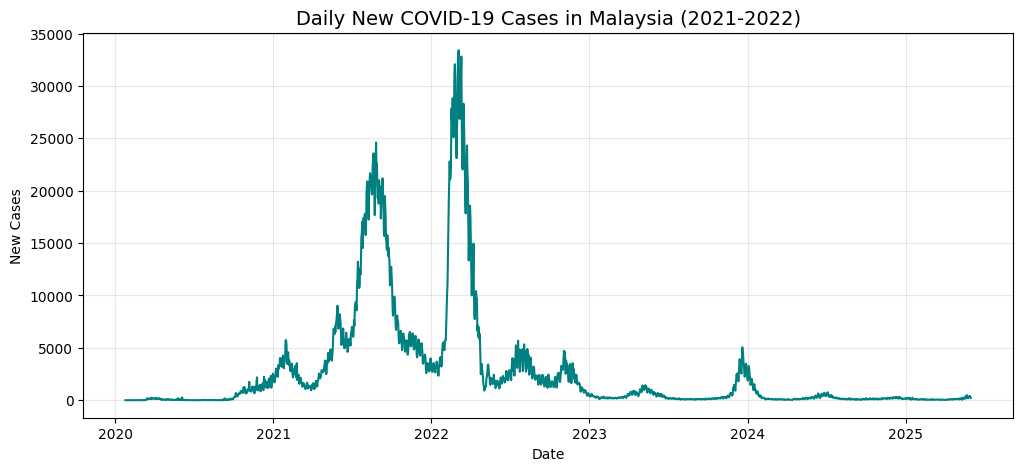

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['cases_new'], color='teal')
plt.title('Daily New COVID-19 Cases in Malaysia (2021-2022)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('New Cases')
plt.grid(alpha=0.3)
plt.show()

**💬 Discuss:** How many distinct "waves" (peaks) can you count in the chart above? What might explain each wave (festive seasons, new variants, reopening of borders)?

## Comparing Cases vs. Deaths

Plotting two related lines together lets us compare their patterns. Did deaths rise and fall along with cases, or did the pattern change over time (for example, after vaccination became widespread)?

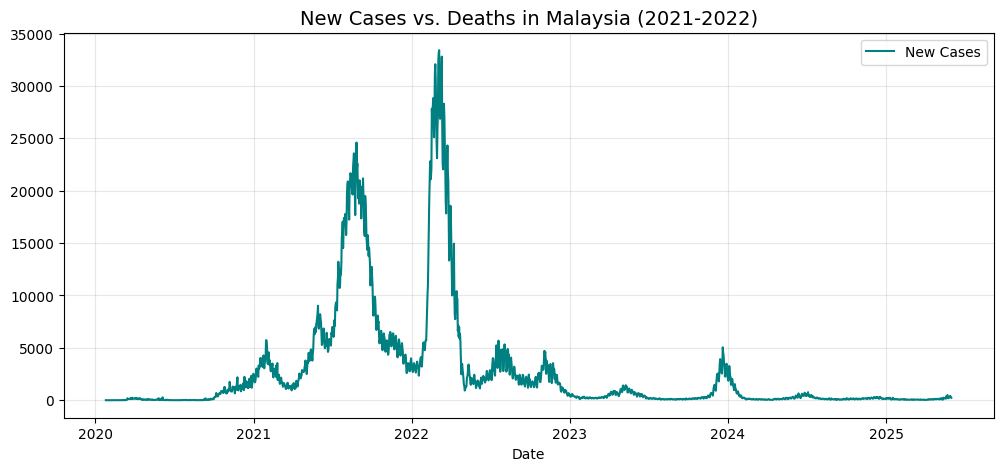

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['cases_new'], label='New Cases', color='teal')
plt.title('New Cases vs. Deaths in Malaysia (2021-2022)', fontsize=14)
plt.xlabel('Date')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Vaccination Progress Over Time

`vax_cumul_fully_vaccinated` is a **cumulative (running total)** column — it only ever goes up. Its shape tells us how fast the vaccination rollout progressed.

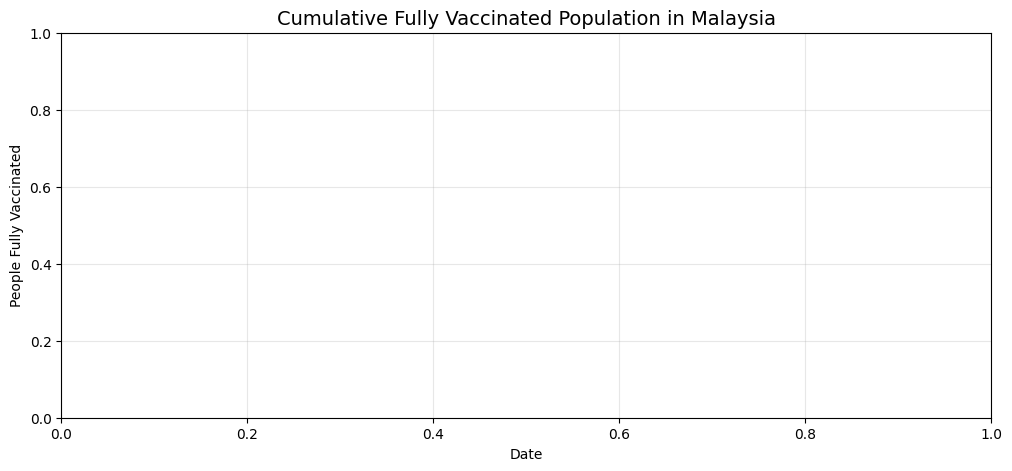

In [ ]:
plt.figure(figsize=(12, 5))
plt.title('Cumulative Fully Vaccinated Population in Malaysia', fontsize=14)
plt.xlabel('Date')
plt.ylabel('People Fully Vaccinated')
plt.grid(alpha=0.3)
plt.show()

**💬 Discuss:** Where does the curve rise steepest? What does that tell us about the speed of the vaccine rollout during that period?

## Step 10 — Finding the Peak: Identifying the Worst Day

`idxmax()` finds the row with the highest value in a column — instantly pinpointing Malaysia's worst day for new cases.

In [ ]:
peak_day = df.loc[df['cases_new'].idxmax()]
print("📌 Malaysia's peak day for new COVID-19 cases:")


📌 Malaysia's peak day for new COVID-19 cases:


This is a simple example of moving from **Descriptive** ("what happened") toward **Diagnostic Analytics** ("why did it happen") —
a good analyst would now research what was happening in Malaysia around that date (e.g. a new variant, an event, a policy change).

## 🏢 Bonus Exercise: Applying This to Business Data

The exact same code works on **any** time-series dataset — not just COVID-19! Imagine `cases_new` was replaced with **daily sales**, and `cases_active` was replaced with **open customer support tickets**.

**Try it yourself:** edit the code below to plot `cases_recovered` instead of `cases_new` (this represents something like "orders completed per day" in a business context).

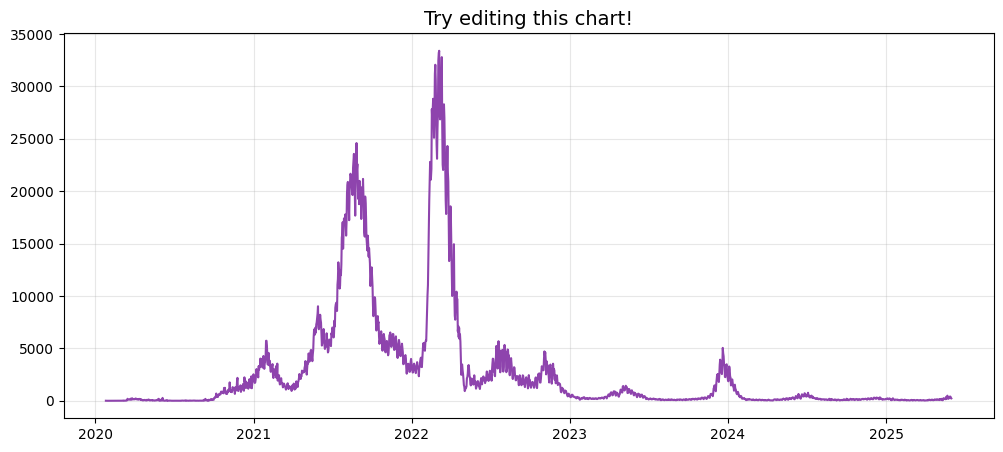

In [ ]:
# ✏️ TODO: change 'cases_new' below to 'cases_recovered' and re-run this cell
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['cases_new'], color='#8E44AD')
plt.title('Try editing this chart!', fontsize=14)
plt.grid(alpha=0.3)
plt.show()

## 🏥 Bonus Exercise: Applying This to Healthcare Planning

**Try it yourself:** using what you've learned, calculate the **average number of active cases** (`cases_active`) — this is similar to
estimating average daily hospital bed occupancy, which planners use to decide how many beds to keep ready.

Write your own line of code in the empty cell below. *Hint: it looks just like the `average_new_cases` line from Step 6.*

In [ ]:
# ✏️ Write your own code here to calculate the average of 'cases_active'
# Hint: average_active = df['cases_active'].mean()


## 🎉 Well Done!

You have just completed a full, real data analytics workflow:

**Collect → Clean → Explore → Analyze → Communicate**

You loaded real government data, cleaned it, summarized it with statistics, and turned it into charts that reveal insight — the exact same
process used by analysts in business and healthcare every day.

---
### 📚 Data Source
Ministry of Health (MoH) Malaysia — COVID-19 Public Data
`github.com/MoH-Malaysia/covid19-public` (accessed for this course; data trimmed to 1 Jan 2021 – 31 Dec 2022 for teaching purposes)

### ➡️ Next Steps
- Re-run this notebook and try changing chart colours or titles
- Try plotting a different column
- Explore more open datasets at **data.gov.my**

**Course:** Data Analytics for Business and Healthcare
